In [95]:
import cv2
import numpy as np
from matplotlib import pyplot as plt


TAREA: Los ejemplos ilustrativos anteriores permiten saber el número de monedas presentes en la imagen. ¿Cómo saber la cantidad de dinero presente en ella? Sugerimos identificar de forma interactiva (por ejemplo haciendo clic en la imagen) una moneda de un valor determinado en la imagen (por ejemplo de 1€). Tras obtener esa información y las dimensiones en milímetros de las distintas monedas, realiza una propuesta para estimar la cantidad de dinero en la imagen. Muestra la cuenta de monedas y dinero sobre la imagen. No hay restricciones sobre utilizar medidas geométricas o de color. 

Una vez resuelto el reto con la imagen ideal proporcionada, captura una o varias imágenes con monedas. Aplica el mismo esquema, tras identificar la moneda del valor determinado, calcula el dinero presente en la imagen. ¿Funciona correctamente? ¿Se observan problemas?

Nota: Para establecer la correspondencia entre píxeles y milímetros, comentar que la moneda de un euro tiene un diámetro de 23.25 mm. la de 50 céntimos de 24.35, la de 20 céntimos de 22.25, etc. 

Extras: Considerar que la imagen pueda contener objetos que no son monedas y/o haya solape entre las monedas. Demo en vivo. 



In [96]:
# para el texto
font = cv2.FONT_HERSHEY_SIMPLEX
color = (0, 0, 0)

# leemos la imagen
img = cv2.imread('Monedas.jpg')

# hago la imagen más pequeña para que quepa en la pantalla
escala = 0.5
ancho = int(img.shape[1] * escala)
alto = int(img.shape[0] * escala)
img = cv2.resize(img, (ancho, alto), interpolation=cv2.INTER_AREA)

# paso la imagen a grises
img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# se establece el umbral
umbral = 200
th1,img_th1 = cv2.threshold(img_gris,umbral,255,cv2.THRESH_BINARY_INV)

# se obtienen los contornos externos
contornos, hierarchy = cv2.findContours(img_th1, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

#dibujamos estos contornos externos
img_contornos = img.copy()
cv2.drawContours(img_contornos, contornos, -1, (0, 255, 0), 2)

# Variable para el tamaño de la de un euro
tamaño_moneda_euro = None
# Imagen para mostrar en la ventana
img_display = None

def calcular_dinero():
    global img_display

    # aquí se calcula el dinero en función del tamaño de las monedas
    if tamaño_moneda_euro == None:
        print("Primero haz click en la moneda de un euro.")
        return
    
    numero_monedas = 0
    dinero = 0

    # Recorremos todos los contornos
    for c in contornos:
        #Área del contorno
        area = cv2.contourArea(c)
        if area > 10:
            relacion = round(area / tamaño_moneda_euro, 2)

            if 0.95 <= relacion <= 1.05:
                dinero += 1
            elif relacion <= 0.5: # Aproximadamente 1 céntimo
                dinero += 0.01
            elif 0.65 <= relacion <= 0.69: # Aproximadamente 2 céntimos
                dinero += 0.02
            elif 0.8 <= relacion <= 0.84: # Aproximadamente 5 céntimos
                dinero += 0.05
            elif 0.7 <= relacion <= 0.74: # Aproximadamente 10 céntimos
                dinero += 0.10
            elif 0.9 <= relacion <= 0.95: # Aproximadamente 20 céntimos
                dinero += 0.20
            elif 1.05 <= relacion <= 1.11: # Aproximadamente 50 céntimos
                dinero += 0.50
            elif relacion >= 1.24: # Aproximadamente 2 euros
                dinero += 2.00

            numero_monedas += 1

    # Mostramos los resultados
    cv2.putText(img_display, f"Monedas: {numero_monedas}", (10, 30), font, 1, color, 2)
    cv2.putText(img_display, f"Dinero: {dinero}", (10, 60), font, 1, color, 2)
    cv2.imshow("Detector de monedas", img_display)
    print(f"Número de monedas detectadas: {numero_monedas}")
    print(f"Dinero total estimado: {dinero}\n")

def evento_click(event, x, y, flags, param):
    # para manejar el evento al hacer click
    global tamaño_moneda_euro, img_display

    if event == cv2.EVENT_LBUTTONDOWN:
        print(f"Click en coordenadas: {x}, {y}")

        # Buscamos el contorno
        for c in contornos:
            result = cv2.pointPolygonTest(c, (x, y), False)
            if result >= 0:
                area = cv2.contourArea(c)
                tamaño_moneda_euro = area
                print(f"Moneda de un euro seleccionada, su área es: {area}")

                # Creo la nueva imagen marcando la moneda seleccionada y la muestro en la ventana
                img_display = img_contornos.copy()
                cv2.drawContours(img_display, [c], -1, (0, 0, 255), 3)
                cv2.imshow("Detector de monedas", img_display)
            
                # calculo el dinero que hay en la imagen
                calcular_dinero()
                break
        

# creo una ventana para poder detectar el click, asigno el evento y muestro la imagen
cv2.namedWindow("Detector de monedas")
cv2.setMouseCallback("Detector de monedas", evento_click)
cv2.imshow('Detector de monedas', img_contornos)

# esperamos a que se pulse una tecla y cerramos
cv2.waitKey(0)
cv2.destroyAllWindows()

El objetivo de la siguiente tarea, descrita más abajo, es desarrollar tu propio clasificador basado únicamente en heurísticas basadas en características geométricas y/o de apariencia, a partir de las imágenes completas de las partículas de cada tipo, debiendo mostrar la bondad del clasificador haciendo uso de métricas para ello sobre las anotaciones de la imagen de test *MPs_test.png*. La ejecución de la celda requiere instalar el paquete scikit-learn.

TAREA: La tarea consiste en extraer características (geométricas y/o visuales) de las tres imágenes completas de partida, y *aprender* patrones que permitan identificar las partículas en nuevas imágenes. Para ello se proporciona como imagen de test *MPs_test.jpg* y sus correpondientes anotaciones *MPs_test_bbs.csv* con la que deben obtener las métricas para su propuesta de clasificación de microplásticos, además de la matriz de confusión. La matriz de confusión permitirá mostrar para cada clase el número de muestras que se clasifican correctamente de dicha clase, y el número de muestras que se clasifican incorrectamente como perteneciente a una de las otras dos clases.

En el trabajo [SMACC: A System for Microplastics Automatic Counting and Classification](https://doi.org/10.1109/ACCESS.2020.2970498), las características geométricas utilizadas fueron:

- Área en píxeles
- Perímetro en píxeles
- Compacidad (relación entre el cuadrado del perímetro y el área de la partícula)
- Relación del área de la partícula con la del contenedor
- Relación del ancho y el alto del contenedor
- Relación entre los ejes de la elipse ajustada
- Definido el centroide, relación entre las distancias menor y mayor al contorno

Si no se quedan satisfechos con la segmentación obtenida, es el mundo real, también en el README comento técnicas recientes de segmentación, que podrían despertar su curiosidad.

Sección de importación de las librerías que necesitamos

In [97]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import random
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import csv
from sklearn.preprocessing import StandardScaler

Función para detectar características de un contorno

In [98]:

def detectFeatures(contour, image_hsv):

    # Calculamos el área en píxeles
    area = cv2.contourArea(contour)

    # Calculamos el perímetro en píxeles
    perimeter = cv2.arcLength(contour, True)

    # Calculamos la compacidad (relación entre el cuadrado del perímetro y el área)
    compacity = (perimeter ** 2) / area if area > 0 else 0

    # Calculamos el rectángulo envolvente y la relación de aspecto
    x, y, w, h = cv2.boundingRect(contour)
    aspect_ratio = w / h if h > 0 else 0

    # Calculamos la relación área contorno / área rectángulo
    rect_area = w * h
    area_ratio = area / rect_area if rect_area > 0 else 0

    # Calculamos la relación entre los ejes de la elipse (excentricidad)
    if len(contour) >= 5:  # fitEllipse necesita al menos 5 puntos
        ellipse = cv2.fitEllipse(contour)
        (center, axes, orientation) = ellipse
        majoraxis_length = max(axes)
        minoraxis_length = min(axes)
        eccentricity = np.sqrt(1 - (minoraxis_length / majoraxis_length) ** 2)
    else:       
        eccentricity = 0

    # Calculamos la relación entre distancias mínima y máxima al centroide
    M = cv2.moments(contour)
    if M["m00"] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        distancias = np.sqrt((contour[:,0,0] - cx)**2 + (contour[:,0,1] - cy)**2)
        relation = distancias.min() / distancias.max() if distancias.max() > 0 else 0
    else:
        relation = 0


     # Características de color 
    mask = np.zeros(image_hsv.shape[:2], dtype=np.uint8)
    cv2.drawContours(mask, [contour], -1, 255, -1)  # máscara binaria del contorno

    # Extraemos los valores HSV dentro del contorno
    h_values = image_hsv[:, :, 0][mask == 255]
    s_values = image_hsv[:, :, 1][mask == 255]
    v_values = image_hsv[:, :, 2][mask == 255]

    # Calculamos medias y desviaciones estándar de H, S, V
    mean_h = np.mean(h_values) if len(h_values) > 0 else 0
    mean_s = np.mean(s_values) if len(s_values) > 0 else 0
    mean_v = np.mean(v_values) if len(v_values) > 0 else 0
    std_h = np.std(h_values) if len(h_values) > 0 else 0
    std_s = np.std(s_values) if len(s_values) > 0 else 0
    std_v = np.std(v_values) if len(v_values) > 0 else 0

    # Devolvemos todas las características
    return {
        "area": area,
        "perimeter": perimeter,
        "compacity": compacity,
        "aspect_ratio": aspect_ratio,
        "area_ratio": area_ratio,
        "eccentricity": eccentricity,
        "relation": relation,
        "mean_h": mean_h,
        "mean_s": mean_s,
        "mean_v": mean_v,
        "std_h": std_h,
        "std_s": std_s,
        "std_v": std_v
    }


Función para extraer el vector de características medias de una imagen

In [99]:

def extractFeatureMeanVector(image_path):
    # Leemos la imagen
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Si no se puede leer la imagen, devolvemos una lista vacía
    if img is None:
        print(f"Error al leer la imagen {image_path}")
        return []
    
    # Aplicamos un desenfoque gaussiano para reducir el ruido
    gaussianBlur = cv2.GaussianBlur(img, (5, 5), 0)

    # Aplicamos un umbral adaptativo para segmentar la imagen
    adaptiveThreshold = cv2.adaptiveThreshold(gaussianBlur, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY_INV, 11, 2)

    # Encontramos los contornos en la imagen umbralizada
    contours, hierarchy = cv2.findContours(adaptiveThreshold, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Leemos la imagen en color para extraer características de color
    img_color = cv2.imread(image_path, cv2.IMREAD_COLOR)
    image_hsv = cv2.cvtColor(img_color, cv2.COLOR_BGR2HSV)

    # Declaramos la lista  donde van a estar las características de todos los contornos
    features_list = []

    # Recorremos cada contorno y calculamos sus características para meterlas en la lista
    for c in contours:
        # Filtramos contornos muy pequeños o muy grandes
        if cv2.contourArea(c) < 100 or cv2.contourArea(c) > 2000:  # ajustar el valor según el tamaño real
            continue
        features = detectFeatures(c, image_hsv)
        features_list.append(features)


    # Sacamos la media de cada característica
    mean_area = np.mean([f["area"] for f in features_list])
    mean_perimeter = np.mean([f["perimeter"] for f in features_list])
    mean_compacity = np.mean([f["compacity"] for f in features_list])
    mean_aspect_ratio = np.mean([f["aspect_ratio"] for f in features_list])
    mean_area_ratio = np.mean([f["area_ratio"] for f in features_list])
    mean_eccentricity = np.mean([f["eccentricity"] for f in features_list])
    mean_relation = np.mean([f["relation"] for f in features_list])
    mean_h = np.mean([f["mean_h"] for f in features_list])
    mean_s = np.mean([f["mean_s"] for f in features_list])
    mean_v = np.mean([f["mean_v"] for f in features_list])
    std_h = np.mean([f["std_h"] for f in features_list])
    std_s = np.mean([f["std_s"] for f in features_list])
    std_v = np.mean([f["std_v"] for f in features_list])

    # Devolvemos el vector de medias características
    return [mean_area, mean_perimeter, mean_compacity, mean_aspect_ratio,
            mean_area_ratio, mean_eccentricity, mean_relation,
            mean_h, mean_s, mean_v, std_h, std_s, std_v]

Sección para extraer los vectores de características medias de las imágenes de referencia (Entrenamiento)

In [100]:
# Calculamos el vector medio de características para cada clase
mean_vectors = {
    "FRA": extractFeatureMeanVector("FRA.png"),
    "PEL": extractFeatureMeanVector("PEL.png"),
    "TAR": extractFeatureMeanVector("TAR.png")
}

# Declaramos los nombres de las características para luego mostrarlas
feature_names = [
    "Área media",
    "Perímetro medio",
    "Compacidad media",
    "Relación de aspecto media",
    "Relación área/elipse media",
    "Excentricidad media",
    "Relación centroide-contorno media",
    "Tono (H) medio",
    "Saturación (S) media",
    "Brillo (V) medio",
    "Desviación tono (H)",
    "Desviación saturación (S)",
    "Desviación brillo (V)"
]

# Mostramos resultados
for label, mean_vector in mean_vectors.items():
    print(f"=== {label} ===")
    for name, value in zip(feature_names, mean_vector):
        print(f"{name}: {value:.4f}")
    print()


=== FRA ===
Área media: 600.0000
Perímetro medio: 338.4994
Compacidad media: 195.6726
Relación de aspecto media: 1.6294
Relación área/elipse media: 0.1725
Excentricidad media: 0.8410
Relación centroide-contorno media: 0.1062
Tono (H) medio: 25.9733
Saturación (S) media: 25.2313
Brillo (V) medio: 116.9689
Desviación tono (H): 6.7211
Desviación saturación (S): 8.4155
Desviación brillo (V): 5.4600

=== PEL ===
Área media: 800.2500
Perímetro medio: 397.7325
Compacidad media: 208.4716
Relación de aspecto media: 0.9096
Relación área/elipse media: 0.1752
Excentricidad media: 0.6282
Relación centroide-contorno media: 0.3671
Tono (H) medio: 25.4120
Saturación (S) media: 36.8819
Brillo (V) medio: 98.3987
Desviación tono (H): 6.9501
Desviación saturación (S): 11.1332
Desviación brillo (V): 5.2040

=== TAR ===
Área media: 1428.5000
Perímetro medio: 158.7719
Compacidad media: 17.6649
Relación de aspecto media: 0.9046
Relación área/elipse media: 0.6269
Excentricidad media: 0.6868
Relación centroide-

NORMALIZACIÓN Y PESOS (ENTRENAMIENTO)

La normalización es importante porque algunas características pueden tener valores muy grandes (por ejemplo, el área de un objeto) y otras valores muy pequeños (como la excentricidad). Si no se normalizan, las características con valores numéricos grandes podrían dominar los cálculos, incluso si no son las más relevantes para diferenciar las clases.

Para conseguir esto, se resta la media y se divide entre la desviación estándar para cada característica.
El resultado es que todos los valores quedan centrados en 0 (la media) y tienen una escala comparable (desviación estándar ≈ 1).
Para realizar este proceso utilizamos StandardScaler del módulo sklearn.preprocessing, que realiza estos cálculos automáticamente.

Media: valor promedio de una característica.

Desviación estándar: medida de cuánto varían los valores respecto a la media.

Para otorgar la relevancia adecuada a cada característica, se emplean pesos.
Estos valores se definieron mediante prueba y error, observando la salida de la celda anterior, donde se puede apreciar en qué características existen diferencias más significativas entre clases y, por tanto, merecen mayor peso.

In [101]:

# Creamos la matriz de características de referencia
reference_features = np.array([mean_vectors["FRA"], mean_vectors["PEL"], mean_vectors["TAR"]])

# Normalizamos con StandardScaler
scaler = StandardScaler()
scaler.fit(reference_features)

# Normalizamos los vectores de referencia para convertir los valores de las características a una escala comparable(0-1)
mean_FRA_norm = scaler.transform([mean_vectors["FRA"]])[0]
mean_PEL_norm = scaler.transform([mean_vectors["PEL"]])[0]
mean_TAR_norm = scaler.transform([mean_vectors["TAR"]])[0]

# Creamos un diccionario con los vectores normalizados para usarlo posteriormente
mean_vectors_norm = {"FRA": mean_FRA_norm, "PEL": mean_PEL_norm, "TAR": mean_TAR_norm}

# Definimos los pesos para cada característica (ajustables según importancia)
weights = np.array([
    0.5,   # area
    0.5,   # perimeter
    1.5,   # compacity - MUY DIFERENTE entre TAR y otros
    1.0,   # aspect_ratio - FRA muy diferente
    2.0,   # area_ratio - MUY DISCRIMINANTE
    1.0,   # eccentricity
    1.5,   # relation - DISCRIMINANTE
    2.0,   # mean_h - TAR muy diferente
    0.5,   # mean_s
    1.5,   # mean_v - TAR muy bajo
    1.0,   # std_h
    0.5,   # std_s
    0.5    # std_v
])

FASE DE CLASIFICACIÓN Y COMPARACIÓN(TEST)

En esta fase, se utiliza la imagen de test, que contiene todas las clases mezcladas, para predecir las etiquetas utilizando lo aprendido durante el entrenamiento.
A continuación, se comparan las etiquetas predichas con las etiquetas reales declaradas en el archivo CSV, con el fin de evaluar la precisión del modelo.

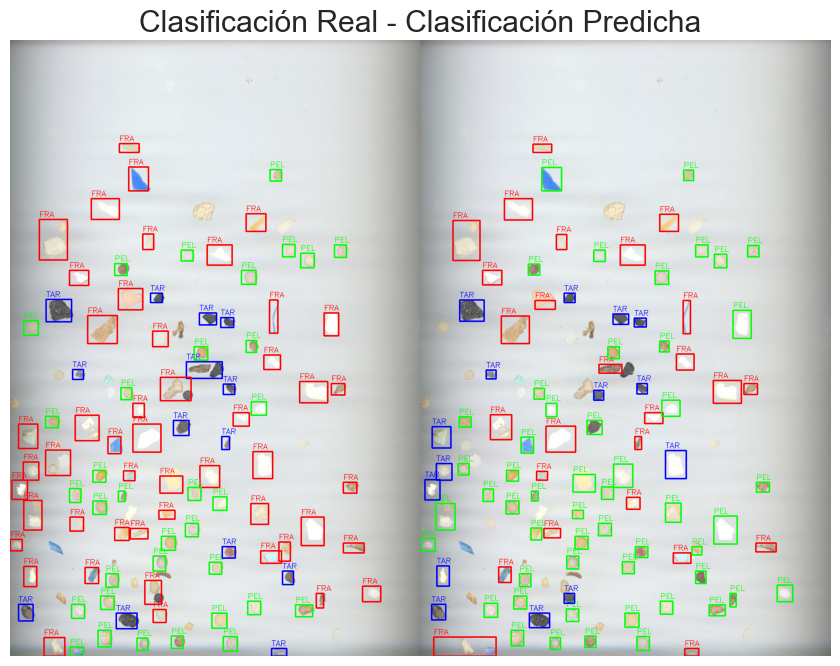

In [102]:
# Declaramos la imagen de test y el archivo CSV con las anotaciones
imagen = "MPs_test.jpg"
csv_file = "MPs_test_bbs.csv"

# Declaramos los colores para cada clase
colores = {
    "FRA": (0, 0, 255), # Rojo
    "PEL": (0, 255, 0), # Verde
    "TAR": (255, 0, 0), # Azul
    "None": (0, 0, 0)   # Negro
}

# Cargamos las anotaciones del CSV en una lista
with open(csv_file, newline="") as file:
    annotations = list(csv.DictReader(file))

# Cargamos la imagen en las diferentes versiones que vamos a usar
imgTest = cv2.imread(imagen)
imgPred_color = cv2.imread(imagen)
imgPred_gray = cv2.cvtColor(imgPred_color, cv2.COLOR_BGR2GRAY)
image_hsv = cv2.cvtColor(imgPred_color, cv2.COLOR_BGR2HSV)

# Detectamos contornos en la imagen de test
blur = cv2.GaussianBlur(imgPred_gray, (5,5), 0)
thresh = cv2.adaptiveThreshold(blur, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                               cv2.THRESH_BINARY_INV, 11, 2)
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Creamos listas para las etiquetas reales y predichas
y_true, y_pred = [], []

# Recorremos las anotaciones y los contornos para clasificar y dibujar
for row in annotations:

    #Cogemos los datos de la anotación
    etiqueta_real = row["label"]
    x_min, y_min, x_max, y_max = map(int, [row["x_min"], row["y_min"], row["x_max"], row["y_max"]])

    # Dibujar anotaciones reales
    color_real = colores[etiqueta_real]
    cv2.rectangle(imgTest, (x_min, y_min), (x_max, y_max), color_real, 2)
    cv2.putText(imgTest, etiqueta_real, (x_min, y_min-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color_real, 1)


    # Inicializamos la etiqueta predicha como "None" por si no encontramos ningún contorno
    matched_label = "None"

    # Buscamos el contorno que esté dentro del bounding box (para conseguir emparejar contorno y anotación de forma adecuada)
    for c in contours:

        # Filtramos contornos muy pequeños o muy grandes
        area = cv2.contourArea(c)
        if area < 100 or area > 2000:
            continue

        # Calculamos el centroide del contorno
        M = cv2.moments(c)
        if M["m00"] == 0:
            continue
        cx, cy = int(M["m10"]/M["m00"]), int(M["m01"]/M["m00"])

        # Comprobamos si el centroide está dentro del bounding box
        if x_min <= cx <= x_max and y_min <= cy <= y_max:
            # Extraemos las características del contorno y creamos el vector de características
            features = detectFeatures(c, image_hsv)
            vector = np.array([features[k] for k in [
                "area","perimeter","compacity","aspect_ratio","area_ratio","eccentricity",
                "relation","mean_h","mean_s","mean_v","std_h","std_s","std_v"
            ]])
            # Normalizamos el vector de características
            vector_norm = scaler.transform([vector])[0]

            # Calculamos la distancia ponderada a cada vector medio y asignamos la etiqueta de la clase más cercana
            distances = {k: np.linalg.norm((vector_norm - v) * weights) for k, v in mean_vectors_norm.items()}

            # Asignamos la etiqueta de la clase más cercana
            matched_label = min(distances.items(), key=lambda x: x[1])[0]

            # Dibujamos la predicción sobre la imagen
            x, y, w, h = cv2.boundingRect(c)
            color = colores[matched_label]
            cv2.rectangle(imgPred_color, (x, y), (x+w, y+h), color, 2)
            cv2.putText(imgPred_color, matched_label, (x, y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

            # Salimos del bucle ya que hemos encontrado el contorno correspondiente
            break

    # Guardamos la etiqueta real y la predicha para evaluar métricas
    y_true.append(etiqueta_real)
    y_pred.append(matched_label)

# Combinamos la imagen con las anotaciones reales y la imagen con las predicciones
combined = np.hstack((
    cv2.cvtColor(imgTest, cv2.COLOR_BGR2RGB),
    cv2.cvtColor(imgPred_color, cv2.COLOR_BGR2RGB)
))

# Mostramos la comparación visual
plt.figure(figsize=(16,8))
plt.imshow(combined)
plt.title("Clasificación Real - Clasificación Predicha")
plt.axis('off')
plt.show()


FASE DE OBTENCIÓN DE RESULTADOS FINALES Y MATRIZ DE CONFUSIÓN
-------------------------------------------------------------

Métricas utilizadas para evaluar el clasificador:


------------------------------------------------------------------------------------------------------------------------------------------	
Accuracy (exactitud):

Qué nos dice: el porcentaje total de aciertos del clasificador.

Para qué sirve: nos da una idea general de si el modelo está funcionando bien, pero puede ser engañoso si las clases están desbalanceadas.

Accuracy = Predicciones correctas / Total de predicciones

-------------------------------------------------------------------------------------------------------------------------------------------

Precision (precisión):

Qué nos dice: de todos los objetos que el modelo predijo como una clase, cuántos realmente pertenecen a esa clase.

Para qué sirve: indica qué tan fiable es la predicción del modelo para cada clase, evitando falsos positivos. Por ejemplo, si predice “FRA” muchas veces pero no siempre acierta, la precisión será baja.

Precision = Verdaderos Positivos / (Verdaderos Positivos + Falsos Positivos)

-------------------------------------------------------------------------------------------------------------------------------------------

Recall (sensibilidad):

Qué nos dice: de todos los objetos que realmente pertenecen a una clase, cuántos fueron correctamente detectados.

Para qué sirve: mide la capacidad del modelo de no dejar pasar objetos de una clase (evitar falsos negativos). Es útil si no queremos que se nos escape ningún objeto relevante.

Recall = Verdaderos Positivos / (Verdaderos Positivos + Falsos Negativos)

-------------------------------------------------------------------------------------------------------------------------------------------
​
F1 Score:

Qué nos dice: balance entre precisión y recall.

Para qué sirve: da una visión global cuando queremos que el modelo sea fiable y no deje pasar objetos, especialmente con clases desbalanceadas. Es útil para comparar modelos o ajustar parámetros.

𝐹1 = 2 * (precisión * recall) / (precisión + recall)

-------------------------------------------------------------------------------------------------------------------------------------------
	​

Matriz de confusión: tabla que compara las etiquetas reales y predichas, mostrando aciertos y errores por clase, incluyendo los objetos no detectados (None).

=== Métricas del clasificador ===
Accuracy (TP/(n))= 0.6288659793814433
Precision (TP/(TP+FP)) = 0.7133756278086175
Recall (TP/(TP+FN)) = 0.6288659793814433
F1 Score (2*(precision*recall)/(precision+recall)) = 0.6286848711822464


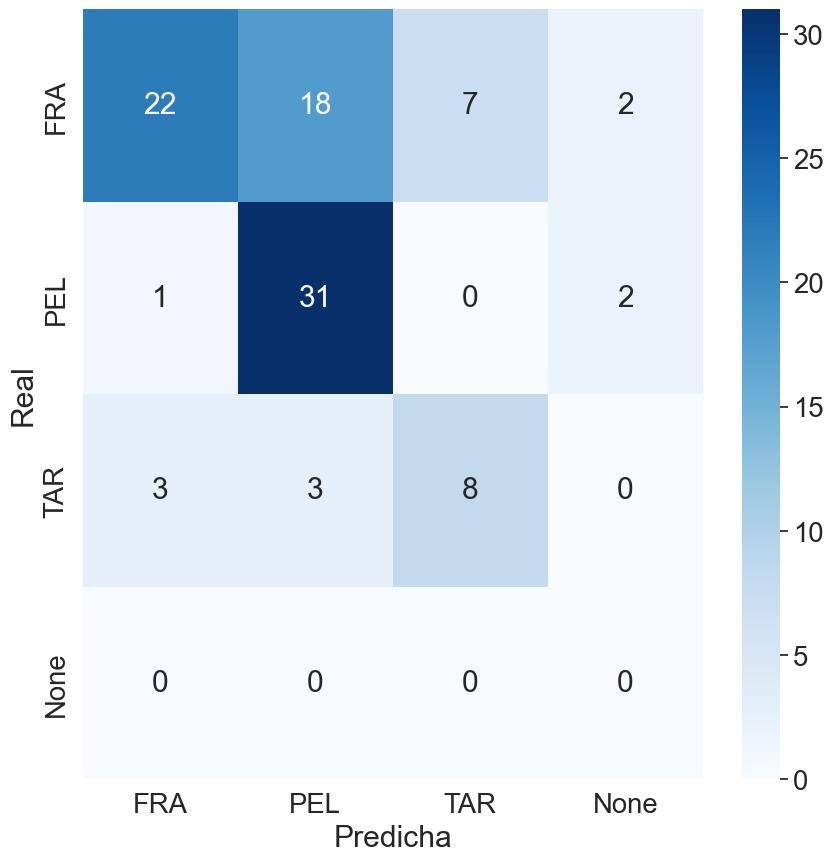

In [103]:
# Calculamos métricas
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1score = f1_score(y_true, y_pred, average='weighted', zero_division=0)

# Mostramos las métricas
print("=== Métricas del clasificador ===")
print(f"Accuracy (TP/(n))= {accuracy}")
print(f"Precision (TP/(TP+FP)) = {precision}")
print(f"Recall (TP/(TP+FN)) = {recall}")
print(f"F1 Score (2*(precision*recall)/(precision+recall)) = {f1score}")

# Creamos la matriz de confusión
clases = ["FRA", "PEL", "TAR", "None"]
conf_matrix = confusion_matrix(y_true, y_pred, labels=clases)

# Mostramos la matriz de confusión
plt.figure(figsize=(10,10))
sns.set(font_scale=1.8)
ax = sns.heatmap(
    conf_matrix, annot=True, fmt='d', cbar=True, cmap='Blues',
    xticklabels=clases, yticklabels=clases
)
ax.set_xlabel("Predicha")
ax.set_ylabel("Real")
plt.show()